# 02. Comparative Segmentations (Manual RFM vs. K-Means RFM).

**Process:**
1. Create table RFM by customer-level (manual): df_rfm_manual
2. Create table RFM by customer-level (Kmeans): df_rfm_kmeans
3. Summary

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Import necessary library

import sys
import os
from pathlib import Path
project_root = os.path.dirname(os.getcwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from utils.rfm_manual import  RFMManual
from utils.rfm_config import ALL_FEATURES
from utils.rfm_feature_engineering import RFMFeatureEngineering
from utils.cluster_model import ClusterAnalysis

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## 1. Create table RFM by customer-level (manual): df_rfm.csv 

In [3]:
rfm_manual = RFMManual(file_name='fact_merge')
df_rfm_manual = rfm_manual._get_concate_df()
df_rfm_manual

D:\03 Data science\00 AIO2025\01 Projects\Case9_ZDS_interview_test\output\fact_merge.csv
D:\03 Data science\00 AIO2025\01 Projects\Case9_ZDS_interview_test\output\fact_merge_clip.csv
Successfully loading df_merge!
Dataframe size: (1048575, 13)
Successfully format date [TransactionDate]
userID
0     382
1     309
8     183
16    116
18    346
Name: Recency, dtype: int64
        Frequency
userID           
0               1
1               1
8               1
16              1
18              1
         Monetary
userID           
0        411663.0
1        105503.0
8       1098496.0
16       286558.0
18       287492.0
Dataframe df_rfm shape before scoring: (583618, 4)
   userID  Recency  Frequency   Monetary
0       0      382          1   411663.0
1       1      309          1   105503.0
2       8      183          1  1098496.0
3      16      116          1   286558.0
4      18      346          1   287492.0
START SCORING R-F-M...
Recency ranking counts: rRecency
5     12864
4     41442

,userID,Recency,Frequency,Monetary,rRecency,rFrequency,rMonetary,rfm_score_groups,Segment,RFM_Scores
0,0,382,1,411663.0,1,1,5,115,Can’t Lose Them,115
1,1,309,1,105503.0,1,1,1,111,Lost,111
2,8,183,1,1098496.0,1,1,5,115,Can’t Lose Them,115
3,16,116,1,286558.0,2,1,3,213,About to Sleep,213
4,18,346,1,287492.0,1,1,3,113,Can’t Lose Them,113
...,...,...,...,...,...,...,...,...,...,...
583613,2174065,255,1,138943.0,1,1,1,111,Lost,111
583614,2174066,7,1,143685.0,5,1,1,511,Recent Customers,511
583615,2174072,37,3,953618.0,3,3,5,335,Loyal Customers,335
583616,2174075,31,1,262489.0,3,1,3,313,Promising,313


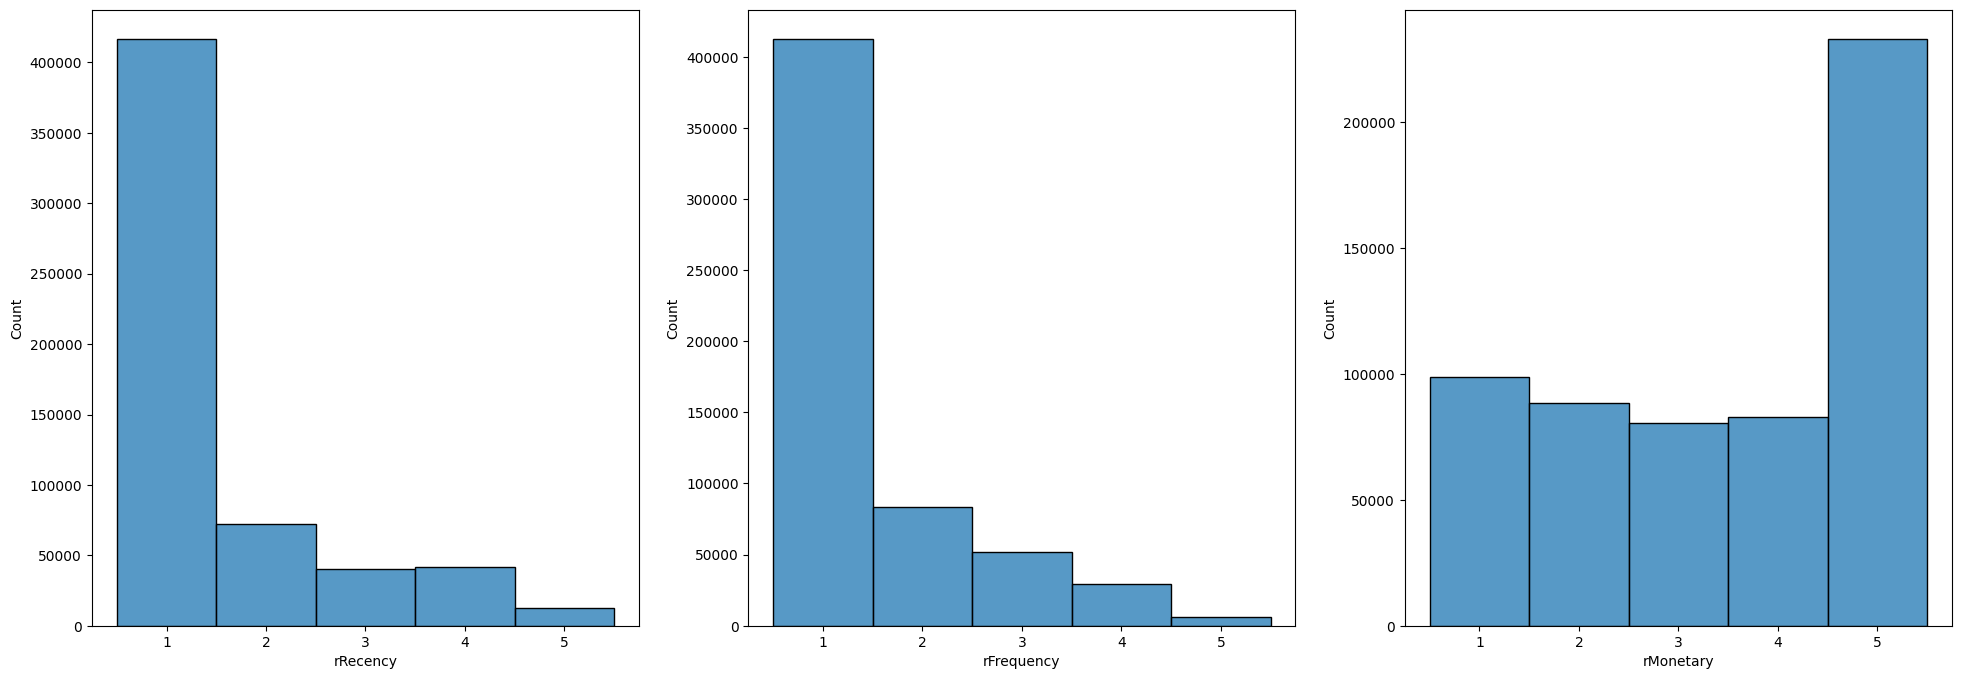

In [4]:
# RFM Manual Visualization
cols = df_rfm_manual.columns[4:7]

fig, axes = plt.subplots(1,3, figsize=(24,8))

for i, col in enumerate(cols):
    sns.histplot(df_rfm_manual[col],
               bins=5,
               ax=axes[i])

plt.show()

## 2. Create table RFM by customer-level (Kmeans): df_rfm_kmeans

In [5]:
rfm_manual2 = RFMManual(file_name='fact_merge_clip.csv')
rfm_manual._export_df_rfm(output_folder=os.path.join(project_root,'output'),filename='rfm_clip')

D:\03 Data science\00 AIO2025\01 Projects\Case9_ZDS_interview_test\output\fact_merge_clip.csv
Successfully loading df_merge!
Dataframe size: (1048575, 13)
Successfully format date [TransactionDate]
File already existed!


D:\03 Data science\00 AIO2025\01 Projects\Case9_ZDS_interview_test\output\rfm_clip.csv
Successfully loading df_rfm!
Dataframe df_rfm size: (583618, 11)
Dataframe customer_features size: (583618, 4)
   userID  Recency  Frequency  Monetary
0       0      382          1    411663
1       1      309          1    105503
2       8      183          1   1098496
3      16      116          1    286558
4      18      346          1    287492
Processing yeojohnson transformation...
Successfully executing yeojohnson transformation and scale data!
Dataframe customer_features_transformed size: (583618, 4)
   userID   Recency  Frequency  Monetary
0       0  1.118749  -0.638136  0.269635
1       1  0.689905  -0.638136 -1.514569
2       8 -0.143079  -0.638136  1.301562
3      16 -0.665761  -0.638136 -0.161698
4      18  0.911070  -0.638136 -0.157692
Successfully exported Raw Features Data!
Successfully exported Transformed Features Data!
Number of feature to plot: 3
ncols, nrows = 3,2


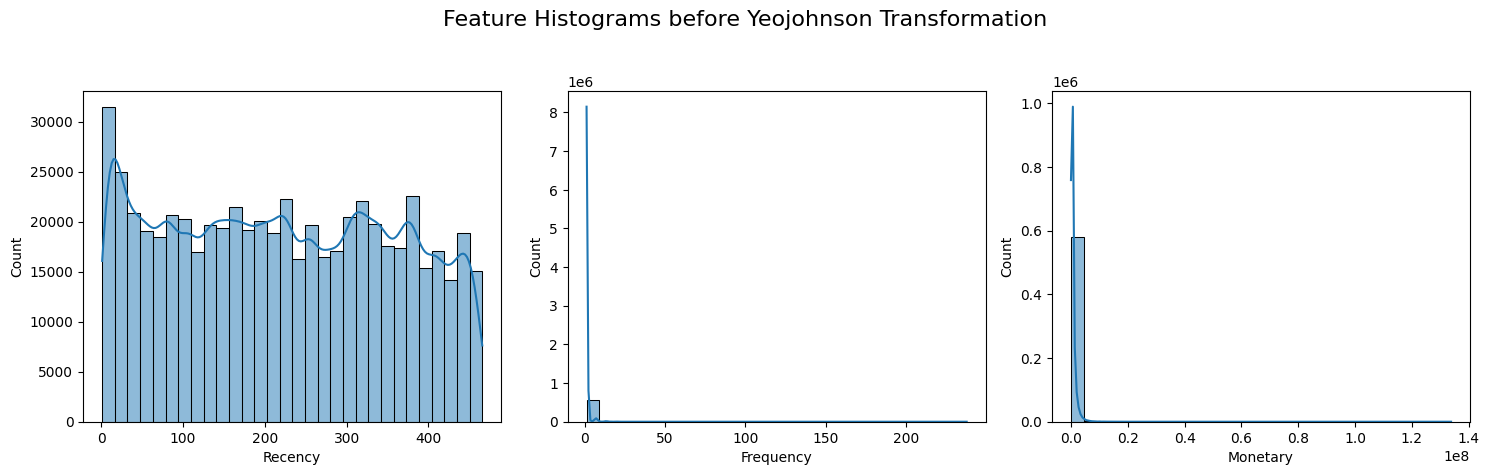

Number of feature to plot: 3
ncols, nrows = 3,2


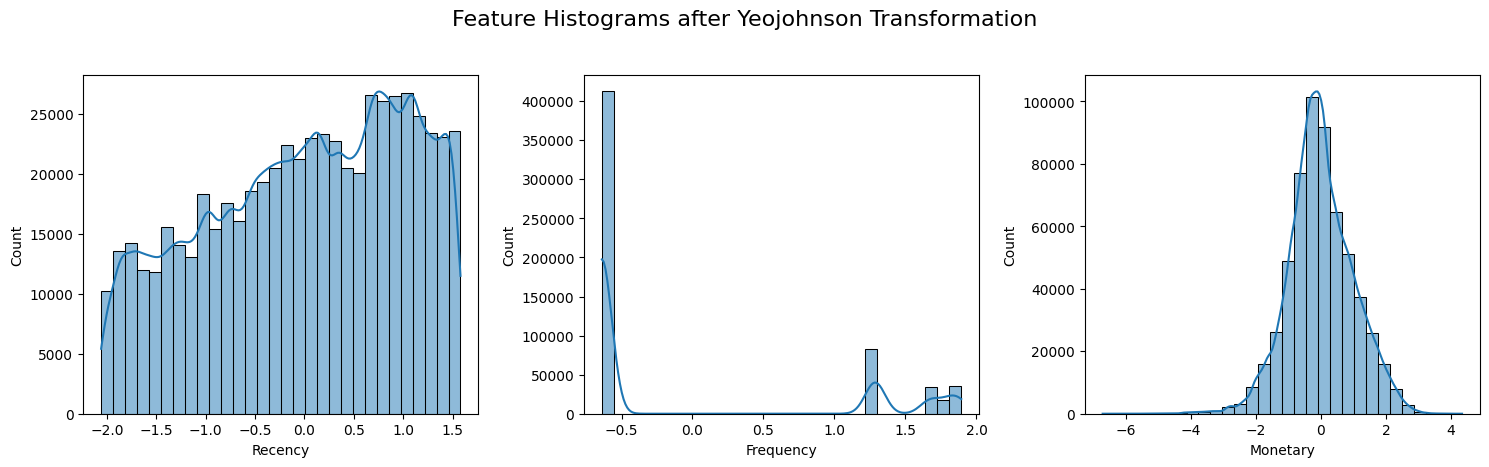

In [6]:
rfm_features = RFMFeatureEngineering(file_name='rfm_clip.csv')

customer_features = rfm_features._create_customer_features()
customer_features_transformed = rfm_features._power_transformation_scaled()

rfm_features._export_feature_files(output_folder=os.path.join(project_root,'output'), customer_feature_name='customer_features',customer_feature_transform_name='customer_feature_transformed')

rfm_features._plot_feature_histogram(transformed=False)
rfm_features._plot_feature_histogram(transformed=True)

In [7]:
raw_features_path= os.path.join(project_root, 'output','customer_features.csv')
transformed_features_path= os.path.join(project_root,'output','customer_feature_transformed.csv')

cluster_model = ClusterAnalysis(raw_features_path, transformed_features_path)
cluster_model._load_features(ALL_FEATURES=ALL_FEATURES)
df_rfm_kmeans_transformed, df_rfm_kmeans = cluster_model._load_file(raw_features_path, transformed_features_path)

print(df_rfm_kmeans.head())
print(df_rfm_kmeans_transformed.head())

Successfully loading file: raw_customer_features: (583618, 3)
Successfully loading file: transformed_customer_features: (583618, 3)
        Recency  Frequency  Monetary
userID                              
0           382          1    411663
1           309          1    105503
8           183          1   1098496
16          116          1    286558
18          346          1    287492
         Recency  Frequency  Monetary
userID                               
0       1.118749  -0.638136  0.269635
1       0.689905  -0.638136 -1.514569
8      -0.143079  -0.638136  1.301562
16     -0.665761  -0.638136 -0.161698
18      0.911070  -0.638136 -0.157692


Transformed feature data shape: (583618, 3)
Completed K=2 | Inertia: 862317 | Silhouette Score: 0.5078
Completed K=3 | Inertia: 596097 | Silhouette Score: 0.4250
Completed K=4 | Inertia: 479587 | Silhouette Score: 0.4054
Completed K=5 | Inertia: 381522 | Silhouette Score: 0.3767
Completed K=6 | Inertia: 416902 | Silhouette Score: 0.3581
Completed K=7 | Inertia: 302504 | Silhouette Score: 0.3302
Completed K=8 | Inertia: 272606 | Silhouette Score: 0.3536
Completed K=9 | Inertia: 236024 | Silhouette Score: 0.3372
Completed K=10 | Inertia: 217438 | Silhouette Score: 0.3295
The optimal number of clusters based on Silhouette Score is: 2


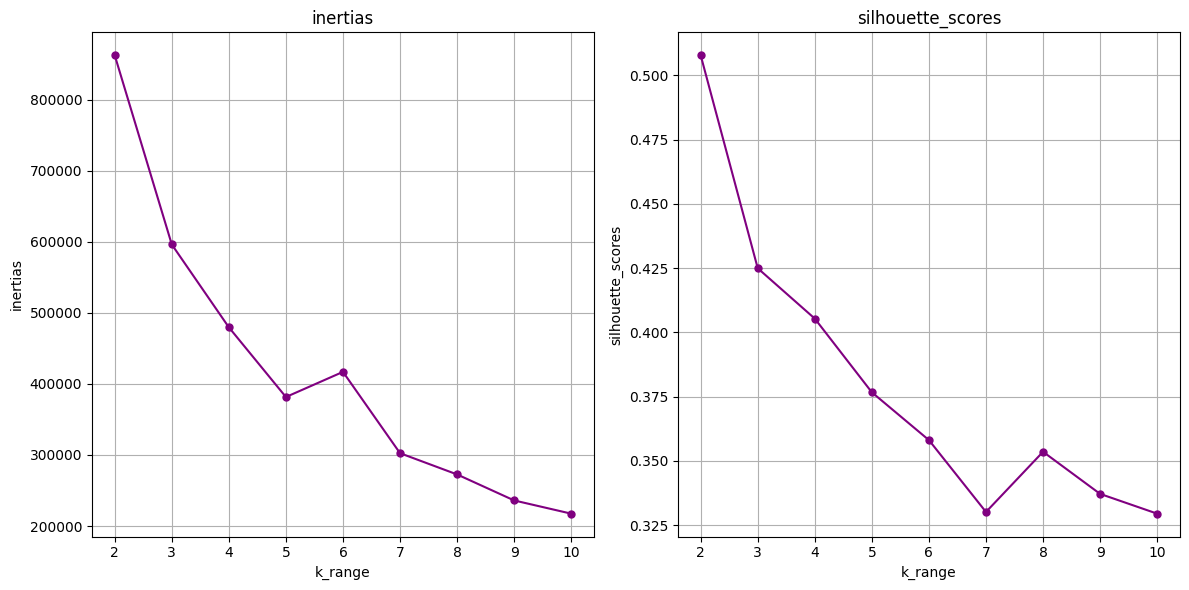

Optimize k by Silhouette Score: k = 2


In [8]:
# Opimal cluster
optimal_clusters = cluster_model._find_optimal_cluster(use_minibatch=True)
cluster_model._plot_optimal_cluster()

Transformed feature data shape: (583618, 3)


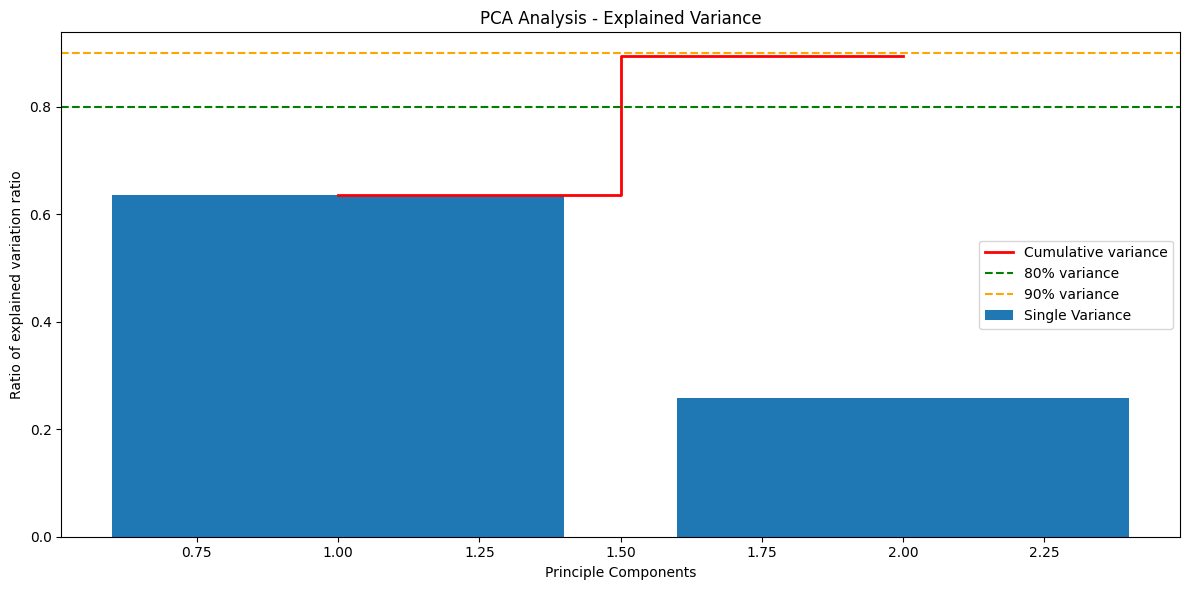

PC1-PC1: 63.52%
PC1-PC2: 89.40%


In [9]:
# PCA Analysis
pca = cluster_model._pca_analysis()
cluster_model._plot_pca_analysis()

In [10]:
# Apply Kmeans 
cluster_results = cluster_model._apply_kmeans(k_values=[2,3,4])

Cluster sizes (k=2)
0    171405
1    412213
Name: count, dtype: int64
Cluster sizes (k=3)
0    158642
1    254708
2    170268
Name: count, dtype: int64
Cluster sizes (k=4)
0     80820
1    254659
2    158642
3     89497
Name: count, dtype: int64


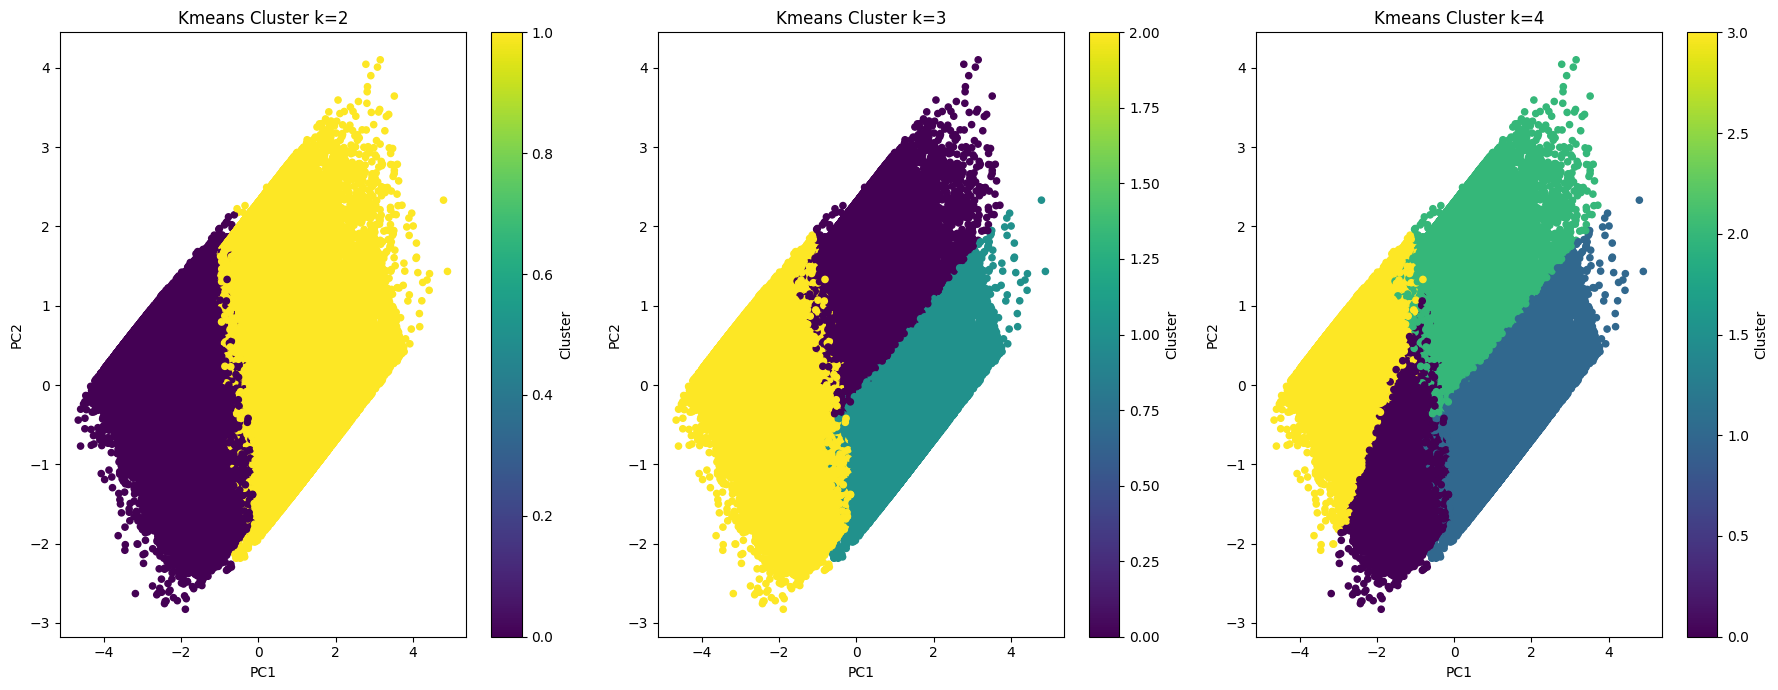

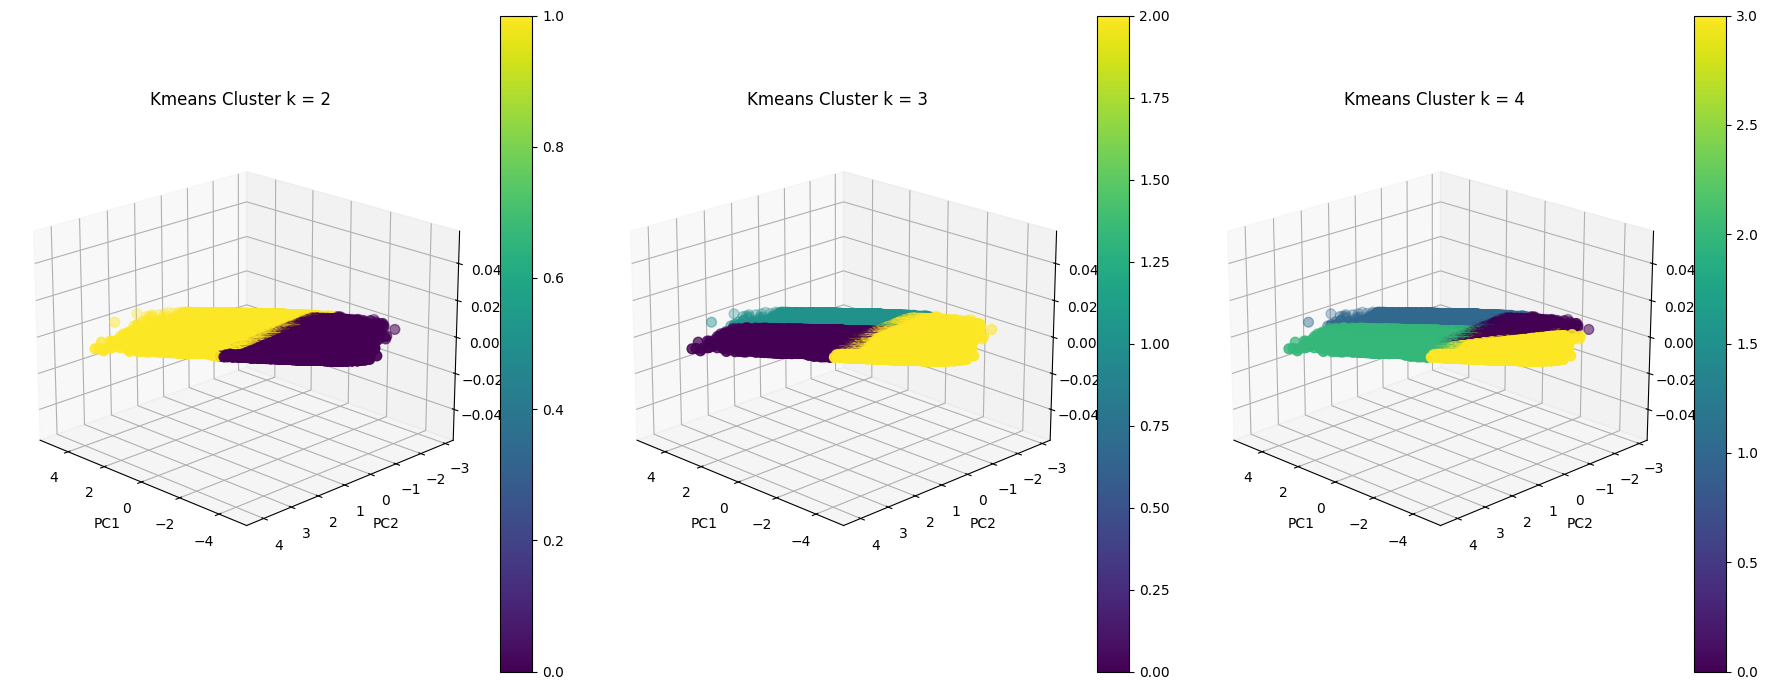

In [11]:
# Visualization 2D-3D
cluster_model._plot_cluster_2d(k_values=[2,3,4])
cluster_model._plot_cluster_3d(k_values=[2,3,4])

In [12]:
# Visualization Cohort Chart
cluster_model._display_cohort_table(k_values = [2,3,4])


=== CLUSTER ANALYSIS K=2 ===
Cluster 0: 171405 users (29.37%)
Cluster 1: 412213 users (70.63%)


,Recency,Frequency,Monetary
clusters_by_k_2,,,
0,147.300000,3.700000,1184299.010000
1,251.410000,1.010000,283073.610000



=== CLUSTER ANALYSIS K=3 ===
Cluster 0: 158642 users (27.18%)
Cluster 1: 254708 users (43.64%)
Cluster 2: 170268 users (29.17%)


,Recency,Frequency,Monetary,clusters_by_k_2
clusters_by_k_3,,,,
0,108.630000,1.000000,284933.400000,0.990000
1,339.360000,1.010000,285458.840000,1.000000
2,148.060000,3.720000,1185016.210000,0.000000



=== CLUSTER ANALYSIS K=4 ===
Cluster 0: 80820 users (13.85%)
Cluster 1: 254659 users (43.63%)
Cluster 2: 158642 users (27.18%)
Cluster 3: 89497 users (15.33%)


,Recency,Frequency,Monetary,clusters_by_k_2,clusters_by_k_3
clusters_by_k_4,,,,,
0,246.870000,2.590000,762461.460000,0.000000,2.000000
1,339.350000,1.010000,285464.140000,1.000000,1.000000
2,108.630000,1.000000,284933.400000,0.990000,0.000000
3,58.970000,4.740000,1566095.440000,0.000000,2.000000


In [13]:
df_rfm_kmeans.head()

,Recency,Frequency,Monetary,clusters_by_k_2,clusters_by_k_3,clusters_by_k_4
userID,,,,,,
0,382,1,411663,1,1,1
1,309,1,105503,1,1,1
8,183,1,1098496,1,0,2
16,116,1,286558,1,0,2
18,346,1,287492,1,1,1


In [14]:
df_rfm_merge = pd.merge(df_rfm_kmeans, df_rfm_manual, on='userID',how='left')
df_rfm_merge

,userID,Recency_x,Frequency_x,Monetary_x,clusters_by_k_2,clusters_by_k_3,clusters_by_k_4,Recency_y,Frequency_y,Monetary_y,rRecency,rFrequency,rMonetary,rfm_score_groups,Segment,RFM_Scores
0,0,382,1,411663,1,1,1,382,1,411663.0,1,1,5,115,Can’t Lose Them,115
1,1,309,1,105503,1,1,1,309,1,105503.0,1,1,1,111,Lost,111
2,8,183,1,1098496,1,0,2,183,1,1098496.0,1,1,5,115,Can’t Lose Them,115
3,16,116,1,286558,1,0,2,116,1,286558.0,2,1,3,213,About to Sleep,213
4,18,346,1,287492,1,1,1,346,1,287492.0,1,1,3,113,Can’t Lose Them,113
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583613,2174065,255,1,138943,1,1,1,255,1,138943.0,1,1,1,111,Lost,111
583614,2174066,7,1,143685,1,0,2,7,1,143685.0,5,1,1,511,Recent Customers,511
583615,2174072,37,3,953618,0,2,3,37,3,953618.0,3,3,5,335,Loyal Customers,335
583616,2174075,31,1,262489,1,0,2,31,1,262489.0,3,1,3,313,Promising,313


### **Detect issue with Kmeans Cluster**

In [15]:
cluster_issue = df_rfm_merge[df_rfm_merge['clusters_by_k_4'] == 2]
cluster_issue_concat = cluster_issue.groupby('clusters_by_k_4').agg({'Segment': lambda x: ','.join(sorted(set(str(k) for k in x if pd.notna(k) ))),
                                                             'RFM_Scores':lambda x: ','.join(sorted(set(str(k) for k in x if pd.notna(k) )))
                                                             })
for i, row in cluster_issue_concat.iterrows():
  print(f'Cluster {i}: \n')
  print(f'Segment: {row['Segment']}\n')
  print(f'RFM Scores: {row['RFM_Scores']}\n')
  print('-'*50)

Cluster 2: 

Segment: About to Sleep,Can’t Lose Them,Hibernating,Lost,Potential Loyalists,Promising,Recent Customers

RFM Scores: 111,112,113,114,115,121,122,131,211,212,213,214,215,221,231,311,312,313,314,315,321,331,411,412,413,414,415,421,431,511,512,513,514,515,521

--------------------------------------------------


### **RFM Segment Final**

In [16]:
segment_counts = rfm_manual._get_segment_breakdown()
print(segment_counts)

           Segment   count
0  Can’t Lose Them  198666
1             Lost  145529
2          At Risk  113460
3        Promising   32492
4      Hibernating   24334
                        Segment   count
0               Can’t Lose Them  198666
1                          Lost  145529
2                       At Risk  113460
3                     Promising   32492
4                   Hibernating   24334
5               Loyal Customers   19665
6              Recent Customers   16067
7                     Champions   12689
8                About to Sleep   11313
9   Customers Needing Attention    8633
10          Potential Loyalists     770


### **Summary**

#### 1. Methodology Overview
This project approaches customer segmentation through two primary methodologies based on the **Recency, Frequency, and Monetary (RFM)** framework:
* **Rule-based Ranking:** Manual segmentation using predefined scoring scales.
* **Unsupervised Learning:** Pattern discovery using the **K-means Clustering** algorithm.

--

#### 2. Approach 1: Rule-based RFM (Manual Scoring)
Customers were assigned scores on a scale of 1-5 for each RFM dimension:

* **Recency (rRecency):** Segmented by time intervals (0-7, 14-30, 30-60, 60-120, and >120 days).
* **Frequency (rFrequency):** Categorized by order counts to reflect loyalty tiers:
    * 1 order: New / Occasional Customers.
    * 2 orders: Returning Customers.
    * 3-4 orders: Regular / Loyal Customers.
    * 5-10 orders: High-Loyalty Customers.
    * Over 10 orders: VIP Customers.
* **Monetary (rMonetary):** Segmented using quintiles (0.2, 0.4, 0.6, 0.8) based on total SalesAmount.

**Data Outcome:** The final manual segmentation dataframe includes: `['userID', 'Recency', 'Frequency', 'Monetary', 'rRecency', 'rFrequency', 'rMonetary', 'rfm_scores_group']`. Final segments were mapped using a standard RFM reference table.

--

#### 3. Approach 2: K-means Clustering
Raw RFM features were utilized as model inputs to identify natural customer groupings.

#### Data Pre-processing
To satisfy K-means requirements regarding cluster shape, density, and distance sensitivity, the following steps were implemented:
* **Outlier Management:** Applied **Clipping** techniques to mitigate the influence of extreme values.
* **Feature Transformation:** Applied **Power Transformation** and **Standard Scaling** to normalize distributions and unify feature scales.
* **Correlation Control:** Monitored high correlations to prevent "implicit weighting," which could bias the centroids towards redundant information.

---

#### 4. Evaluation & Identified Issues
When testing with **K=4**, a significant overlap was detected: **Cluster 2** failed to distinguish between **Potential Loyalists** and **Lost** customers. This indicates that the current model lacks sufficient granularity.

**Root Causes:**
1.  **Feature Sparsity:** Relying solely on 3 RFM features provides an incomplete representation of complex customer behaviors.
2.  **Data Homogeneity:** The current feature set is limited to transaction volume and value, ignoring other qualitative behavioral nuances.

---

#### 5. Next Steps
To address these limitations, a third analysis notebook has been established to test the following enhancements:
* **Feature Expansion:** Increasing the number of input variables
* **Feature Diversification:** Integrating categorical data such as order transaction, preferred channels and transaction period to create more descriptive clusters.